# Data Cleaning

This notebook applies the first cleaning pass to the raw credit card fraud dataset. The main objective is to remove duplicate rows, confirm that the cleaned dataset still preserves the fraud-label distribution, validate the cleaned output, and save the cleaned dataset for downstream feature engineering and modeling.

## 1. Cleaning Objectives

This notebook focuses on the following tasks:

- load the raw dataset from the project data loader
- quantify duplicate rows before cleaning
- remove duplicate transactions using the reusable cleaning utility
- compare class distribution before and after cleaning
- validate the cleaned dataset using the cleaned-data validator
- save the cleaned dataset, summary tables, figures, and a short cleaning report

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Project root not found. Open the notebook from inside the project.")

project_root = find_project_root(Path.cwd())
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import CLEANED_DATA_FILE, PROJECT_ROOT, TARGET_COLUMN
from src.data.data_cleaning import clean_creditcard_data, save_cleaned_data
from src.data.data_loader import load_raw_data
from src.data.data_validation import DataValidationError, validate_cleaned_data

NOTEBOOK_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / "04_data_cleaning"
NOTEBOOK_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "04_data_cleaning"
NOTEBOOK_TABLES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")
print(f"  TARGET_COLUMN     : {TARGET_COLUMN}")
print(f"  Cleaned data path : {CLEANED_DATA_FILE}")
print(f"  Tables dir        : {NOTEBOOK_TABLES_DIR}")
print(f"  Figures dir       : {NOTEBOOK_FIGURES_DIR}")

Imports OK
  TARGET_COLUMN     : Class
  Cleaned data path : /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/data/interim/creditcard_cleaned.csv
  Tables dir        : /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/04_data_cleaning
  Figures dir       : /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/04_data_cleaning


## 2. Load Raw Data

In [2]:
df = load_raw_data()

print("Raw dataset shape:", df.shape)
df.head()

Raw dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Raw Duplicate Summary

In [3]:
raw_row_count = len(df)
raw_duplicate_count = int(df.duplicated().sum())
raw_unique_count = raw_row_count - raw_duplicate_count

raw_duplicate_summary = pd.DataFrame([
    {"metric": "raw_row_count", "value": raw_row_count},
    {"metric": "raw_duplicate_count", "value": raw_duplicate_count},
    {"metric": "raw_unique_count", "value": raw_unique_count},
    {"metric": "raw_duplicate_rate_percent", "value": round((raw_duplicate_count / raw_row_count) * 100, 4)}
])

raw_duplicate_summary.to_csv(NOTEBOOK_TABLES_DIR / "raw_duplicate_summary.csv", index=False)
raw_duplicate_summary

,metric,value
0,raw_row_count,284807.0000
1,raw_duplicate_count,1081.0000
2,raw_unique_count,283726.0000
3,raw_duplicate_rate_percent,0.3796


## 4. Clean the Dataset

In [4]:
df_cleaned = clean_creditcard_data(df)

cleaned_row_count = len(df_cleaned)
cleaned_duplicate_count = int(df_cleaned.duplicated().sum())
rows_removed = raw_row_count - cleaned_row_count

cleaning_summary = pd.DataFrame([
    {"metric": "raw_row_count", "value": raw_row_count},
    {"metric": "cleaned_row_count", "value": cleaned_row_count},
    {"metric": "rows_removed", "value": rows_removed},
    {"metric": "rows_removed_percent", "value": round((rows_removed / raw_row_count) * 100, 4)},
    {"metric": "remaining_duplicate_count", "value": cleaned_duplicate_count}
])

cleaning_summary.to_csv(NOTEBOOK_TABLES_DIR / "cleaning_summary.csv", index=False)
cleaning_summary

,metric,value
0,raw_row_count,284807.0000
1,cleaned_row_count,283726.0000
2,rows_removed,1081.0000
3,rows_removed_percent,0.3796
4,remaining_duplicate_count,0.0000


## 5. Compare Class Distribution Before and After Cleaning

In [5]:
class_distribution_before = pd.DataFrame({
    "count": df[TARGET_COLUMN].value_counts().sort_index(),
    "percent": (df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100).round(4)
})
class_distribution_after = pd.DataFrame({
    "count": df_cleaned[TARGET_COLUMN].value_counts().sort_index(),
    "percent": (df_cleaned[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100).round(4)
})

class_distribution_before.to_csv(NOTEBOOK_TABLES_DIR / "class_distribution_before_cleaning.csv")
class_distribution_after.to_csv(NOTEBOOK_TABLES_DIR / "class_distribution_after_cleaning.csv")

class_distribution_comparison = pd.DataFrame({
    "count_before": class_distribution_before["count"],
    "count_after": class_distribution_after["count"],
    "percent_before": class_distribution_before["percent"],
    "percent_after": class_distribution_after["percent"],
})
class_distribution_comparison.index.name = TARGET_COLUMN
class_distribution_comparison.to_csv(NOTEBOOK_TABLES_DIR / "class_distribution_comparison.csv")
class_distribution_comparison

,count_before,count_after,percent_before,percent_after
Class,,,,
0,284315,283253,99.8273,99.8333
1,492,473,0.1727,0.1667


## 6. Visualize Class Distribution Preservation

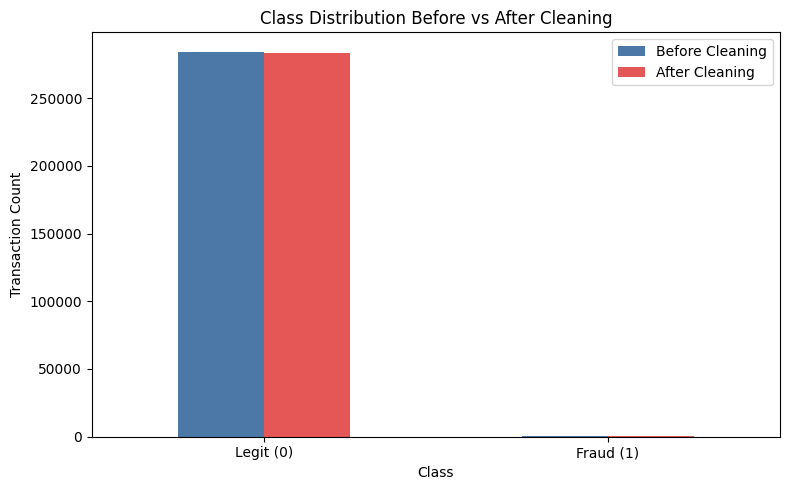

In [6]:
plot_df = pd.DataFrame({
    "Before Cleaning": class_distribution_before["count"],
    "After Cleaning": class_distribution_after["count"],
})
plot_df.index = ["Legit (0)", "Fraud (1)"]

ax = plot_df.plot(kind="bar", figsize=(8, 5), color=["#4C78A8", "#E45756"])
ax.set_title("Class Distribution Before vs After Cleaning")
ax.set_xlabel("Class")
ax.set_ylabel("Transaction Count")
ax.set_xticklabels(plot_df.index, rotation=0)
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "class_distribution_before_after_cleaning.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Validate the Cleaned Dataset

In [7]:
try:
    validate_cleaned_data(df_cleaned)
    cleaned_validation_status = "PASS"
    cleaned_validation_message = "Cleaned dataset passed the implemented validation checks."
except DataValidationError as error:
    cleaned_validation_status = "FAIL"
    cleaned_validation_message = str(error)

cleaned_validation_summary = pd.DataFrame([
    {"check": "duplicate_rows_removed", "status": "PASS" if cleaned_duplicate_count == 0 else "FAIL"},
    {"check": "cleaned_dataset_validation", "status": cleaned_validation_status},
    {"check": "class_labels_preserved", "status": "PASS" if set(df_cleaned[TARGET_COLUMN].unique()) <= {0, 1} else "FAIL"}
])

cleaned_validation_summary.to_csv(NOTEBOOK_TABLES_DIR / "cleaned_validation_summary.csv", index=False)
cleaned_validation_summary

,check,status
0,duplicate_rows_removed,PASS
1,cleaned_dataset_validation,PASS
2,class_labels_preserved,PASS


## 8. Save Cleaned Data

In [8]:
cleaned_data_path = save_cleaned_data(df_cleaned)
print(f"Cleaned dataset saved to: {cleaned_data_path}")

Cleaned dataset saved to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/data/interim/creditcard_cleaned.csv


## 9. Cleaning Conclusion

The first cleaning pass removes duplicate rows while preserving the fraud-label structure required for downstream modeling. The cleaned dataset should now be used as the baseline input for feature engineering, with class imbalance preserved for later model-aware handling rather than altered during cleaning.

## 10. Save Cleaning Report

In [9]:
cleaning_report = f"""# Cleaning Report

## Cleaning Summary

- Raw row count: {raw_row_count}
- Raw duplicate count: {raw_duplicate_count}
- Cleaned row count: {cleaned_row_count}
- Rows removed: {rows_removed}
- Remaining duplicates: {cleaned_duplicate_count}
- Cleaned validation status: {cleaned_validation_status}
- Cleaned validation message: {cleaned_validation_message}

## Key Outcomes

- Duplicate rows were removed using the reusable cleaning utility.
- The cleaned dataset preserves the binary fraud target labels.
- Class imbalance remains present and should be handled during modeling rather than during cleaning.
- The cleaned dataset is ready for the next feature engineering step if validation remains in the pass state.

## Saved Tables

- `reports/tables/04_data_cleaning/raw_duplicate_summary.csv`
- `reports/tables/04_data_cleaning/cleaning_summary.csv`
- `reports/tables/04_data_cleaning/class_distribution_before_cleaning.csv`
- `reports/tables/04_data_cleaning/class_distribution_after_cleaning.csv`
- `reports/tables/04_data_cleaning/class_distribution_comparison.csv`
- `reports/tables/04_data_cleaning/cleaned_validation_summary.csv`
- `reports/tables/04_data_cleaning/cleaning_report.md`

## Saved Figures

- `reports/figures/04_data_cleaning/class_distribution_before_after_cleaning.png`

## Final Judgment

The cleaned dataset removes the identified duplicate-record issue from the raw data while preserving the fraud detection target structure. It is suitable to move forward into feature engineering, with class imbalance retained for careful treatment during modeling and evaluation.
"""

report_path = NOTEBOOK_TABLES_DIR / "cleaning_report.md"
report_path.write_text(cleaning_report, encoding="utf-8")
print(f"Cleaning report saved to: {report_path}")

Cleaning report saved to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/04_data_cleaning/cleaning_report.md


## 11. Next Step

The next notebook should be `05_feature_engineering.ipynb`. It should start from the cleaned dataset, preserve the fraud target labels, apply feature transformations carefully, and save the engineered dataset to the processed data folder.